# Obtaining & exploring dataset

In [1]:
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings("ignore")
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from pts.model.tempflow import TempFlowEstimator

from pts.model.tempflow import TempFlowEstimator_mod
from pts.model.tempflow import TempFlowEstimator_nRelu

from pts import Trainer
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt

In [2]:
dataset = get_dataset("solar_nips", regenerate=False)
#dataset = get_dataset("traffic_nips", regenerate=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
#np.random.seed(12345)
#torch.manual_seed(12345)
#torch.cuda.manual_seed(12345)

In [4]:

''' Para train y val
from gluonts.dataset.field_names import FieldName
import pandas as pd 
from gluonts.dataset.common import ListDataset

def split_train_validation_multivariate(dataset, val_ratio=0.2):
    train_list = list(dataset)
    train_data = []
    val_data = []
    for entry in train_list:
        target = entry[FieldName.TARGET]
        #train_len = int(target.shape[0] * (1 - val_ratio))
        train_target = target[:-24]
        val_target = target[-24:]
        
        train_data.append(
            {k: v for k, v in entry.items() if k != FieldName.TARGET}
        )
        train_data[-1][FieldName.TARGET] = train_target
        
        val_data.append(
            {k: v for k, v in entry.items() if k != FieldName.TARGET}
        )
        val_data[-1][FieldName.TARGET] = val_target
        val_data[-1][FieldName.START] = entry[FieldName.START] + pd.Timedelta(hours=train_target.shape[0])
        
    return ListDataset(train_data, freq="H"), ListDataset(val_data, freq="H")

train_ds, val_ds = split_train_validation_multivariate(dataset.train)

'''



' Para train y val\nfrom gluonts.dataset.field_names import FieldName\nimport pandas as pd \nfrom gluonts.dataset.common import ListDataset\n\ndef split_train_validation_multivariate(dataset, val_ratio=0.2):\n    train_list = list(dataset)\n    train_data = []\n    val_data = []\n    for entry in train_list:\n        target = entry[FieldName.TARGET]\n        #train_len = int(target.shape[0] * (1 - val_ratio))\n        train_target = target[:-24]\n        val_target = target[-24:]\n        \n        train_data.append(\n            {k: v for k, v in entry.items() if k != FieldName.TARGET}\n        )\n        train_data[-1][FieldName.TARGET] = train_target\n        \n        val_data.append(\n            {k: v for k, v in entry.items() if k != FieldName.TARGET}\n        )\n        val_data[-1][FieldName.TARGET] = val_target\n        val_data[-1][FieldName.START] = entry[FieldName.START] + pd.Timedelta(hours=train_target.shape[0])\n        \n    return ListDataset(train_data, freq="H"), Li


## Prepare dataset

In [3]:
train_grouper = MultivariateGrouper(max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

test_grouper = MultivariateGrouper(num_test_dates=int(len(dataset.test)/len(dataset.train)),
                                   max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

#dataset_train = train_grouper(train_ds)
#dataset_val = train_grouper(val_ds)

## Evaluator

In [4]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

## Modelo

## Traffic

In [9]:
#traffic
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)

In [10]:
estimator_mod = TempFlowEstimator_mod(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)

## Solar nips

In [5]:
#Solar nips
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [5]:
estimator_mod = TempFlowEstimator_mod(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=1,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [7]:
estimator_nRelu = TempFlowEstimator_nRelu(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [ ]:
predictor = estimator.train(dataset_train,prefetch_factor = None, )

In [6]:
predictor_mod = estimator_mod.train(dataset_train, prefetch_factor = None)

100%|██████████| 99/99 [00:14<00:00,  6.81it/s, epoch=1/1, avg_loss=125]


In [ ]:
predictor_nRelu = estimator_nRelu.train(dataset_train, prefetch_factor = None)

# Samples

In [7]:
forecast_it, ts_it = make_evaluation_predictions(dataset=dataset_test,
                                             predictor=predictor,
                                             num_samples=100)
forecasts = list(forecast_it)
targets = list(ts_it)

agg_metric, _ = evaluator(targets, forecasts, num_series=len(dataset_test))

NameError: name 'predictor' is not defined

In [10]:
predictor_mod.input_names

['a',
 'target_dimension_indicator',
 'past_time_feat',
 'past_target_cdf',
 'past_observed_values',
 'past_is_pad',
 'future_time_feat']

In [8]:
forecast_it_mod, ts_it = make_evaluation_predictions(dataset=dataset_test,
                                             predictor=predictor_mod,
                                             num_samples=100,
                                             a_scalar = 0.1)
forecasts_mod = list(forecast_it_mod)
targets = list(ts_it)

agg_metric_mod, _ = evaluator(targets, forecasts_mod, num_series=len(dataset_test))

Running evaluation: 7it [00:00, 108.01it/s]


In [ ]:
forecast_it_nRelu, ts_it = make_evaluation_predictions(dataset=dataset_test,
                                             predictor=predictor_nRelu,
                                             num_samples=100)
forecasts_nRelu = list(forecast_it_nRelu)
targets = list(ts_it)

agg_metric_nRelu, _ = evaluator(targets, forecasts_nRelu, num_series=len(dataset_test))

In [9]:
def plot(target, forecast, prediction_length, prediction_intervals=(50.0, 90.0), color='g', fname=None):
    label_prefix = ""
    rows = 5
    cols = 5
    fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
    axx = axs.ravel()
    seq_len, target_dim = target.shape

    ps = [50.0] + [
            50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
        ]

    percentiles_sorted = sorted(set(ps))

    def alpha_for_percentile(p):
        return (p / 100.0) ** 0.3

    for dim in range(0, min(rows * cols, target_dim)):
        ax = axx[dim]

        target[-2 * prediction_length :][dim].plot(ax=ax)

        ps_data = [forecast.quantile(p / 100.0)[:,dim] for p in percentiles_sorted]
        i_p50 = len(percentiles_sorted) // 2

        p50_data = ps_data[i_p50]
        p50_series = pd.Series(data=p50_data, index=forecast.index)
        p50_series.plot(color=color, ls="-", label=f"{label_prefix}median", ax=ax)

        for i in range(len(percentiles_sorted) // 2):
            ptile = percentiles_sorted[i]
            alpha = alpha_for_percentile(ptile)
            ax.fill_between(
                forecast.index,
                ps_data[i],
                ps_data[-i - 1],
                facecolor=color,
                alpha=alpha,
                interpolate=True,
            )
            # Hack to create labels for the error intervals.
            # Doesn't actually plot anything, because we only pass a single data point
            pd.Series(data=p50_data[:1], index=forecast.index[:1]).plot(
                color=color,
                alpha=alpha,
                linewidth=10,
                label=f"{label_prefix}{100 - ptile * 2}%",
                ax=ax,
            )

    legend = ["observations", "median prediction"] + [f"{k}% prediction interval" for k in prediction_intervals][::-1]
    axx[0].legend(legend, loc="upper left")

    if fname is not None:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)


import matplotlib.pyplot as plt


In [ ]:
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

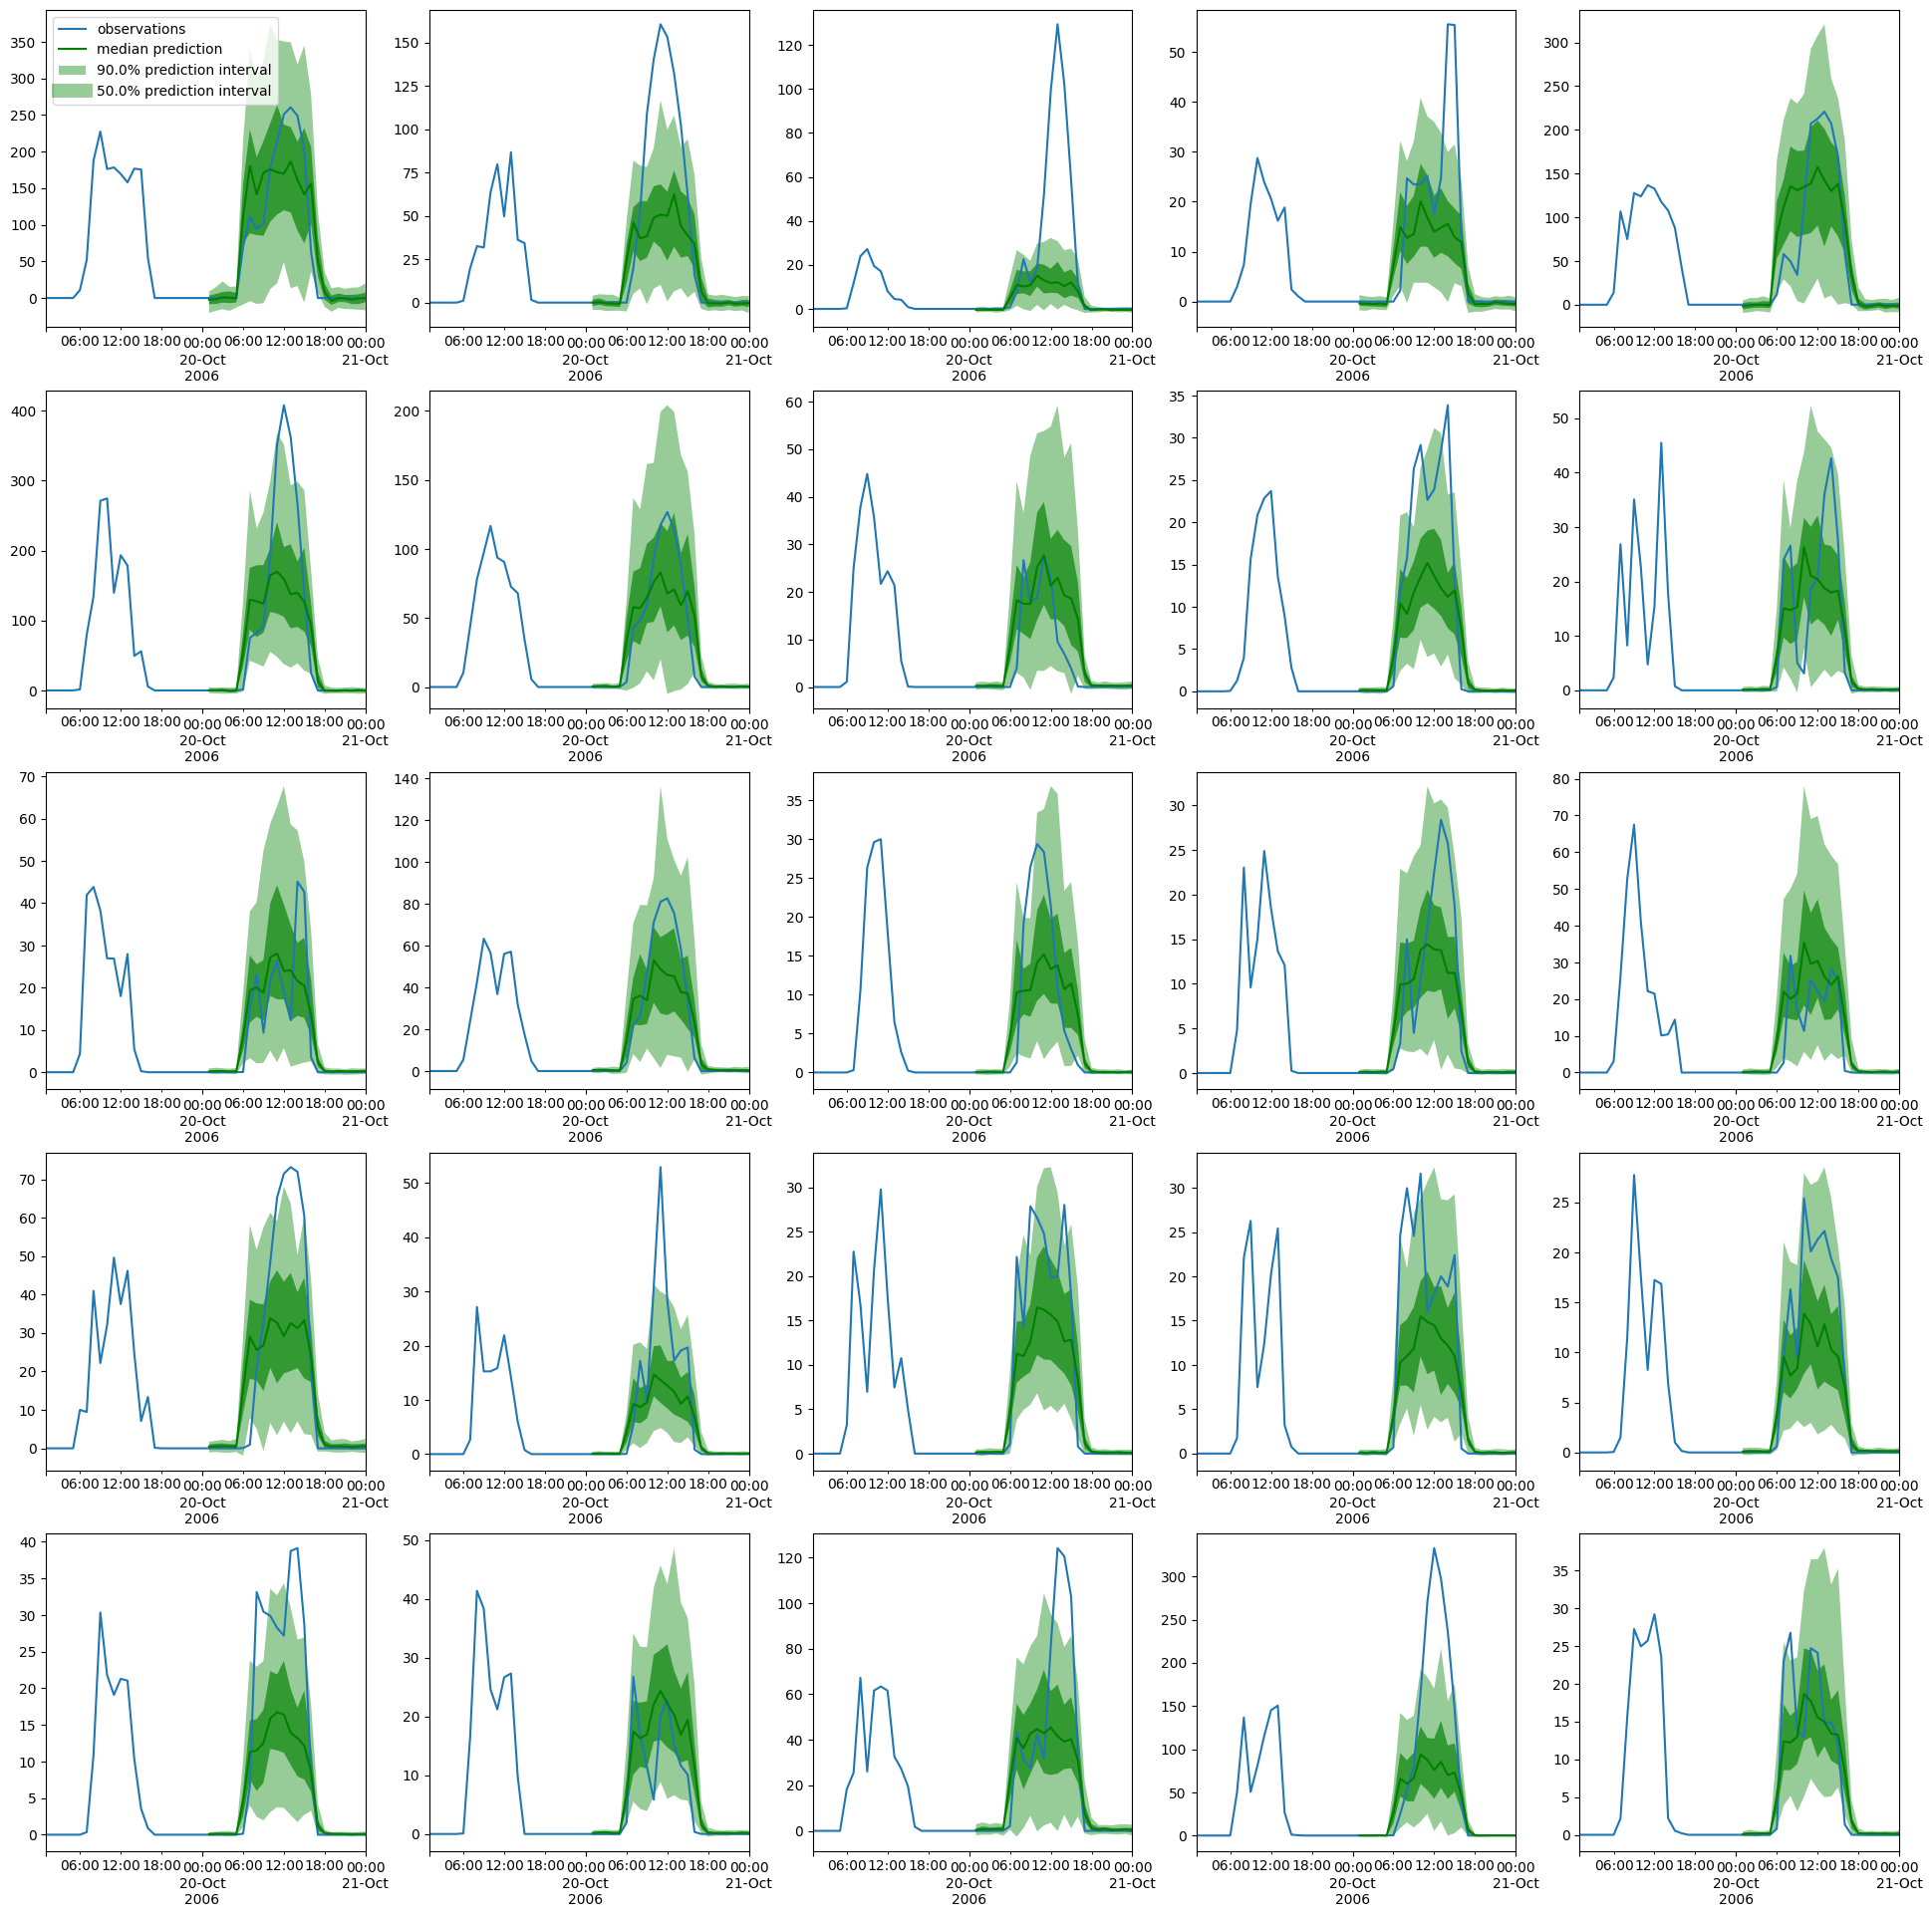

In [10]:
plot(
    target=targets[0],
    forecast=forecasts_mod[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

In [ ]:
plot(
    target=targets[0],
    forecast=forecasts_nRelu[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

# Metrics

In [ ]:

print("CRPS: {}".format(agg_metric['mean_wQuantileLoss']))
print("ND: {}".format(agg_metric['ND']))
print("NRMSE: {}".format(agg_metric['NRMSE']))
print("MSE: {}".format(agg_metric['MSE']))

print("CRPS-Sum: {}".format(agg_metric['m_sum_mean_wQuantileLoss']))
print("ND-Sum: {}".format(agg_metric['m_sum_ND']))
print("NRMSE-Sum: {}".format(agg_metric['m_sum_NRMSE']))
print("MSE-Sum: {}".format(agg_metric['m_sum_MSE']))

In [11]:
#log sigmoid
print("CRPS: {}".format(agg_metric_mod['mean_wQuantileLoss']))
print("ND: {}".format(agg_metric_mod['ND']))
print("NRMSE: {}".format(agg_metric_mod['NRMSE']))
print("MSE: {}".format(agg_metric_mod['MSE']))

print("CRPS-Sum: {}".format(agg_metric_mod['m_sum_mean_wQuantileLoss']))
print("ND-Sum: {}".format(agg_metric_mod['m_sum_ND']))
print("NRMSE-Sum: {}".format(agg_metric_mod['m_sum_NRMSE']))
print("MSE-Sum: {}".format(agg_metric_mod['m_sum_MSE']))

CRPS: 0.42971904754710266
ND: 0.557100602951034
NRMSE: 1.106481596569473
MSE: 1161.3581643235486
CRPS-Sum: 0.38159051247611203
ND-Sum: 0.5008855461758398
NRMSE-Sum: 0.8593893938122055
MSE-Sum: 13149187.619047618


In [ ]:
#relu negativa
print("CRPS: {}".format(agg_metric_nRelu['mean_wQuantileLoss']))
print("ND: {}".format(agg_metric_nRelu['ND']))
print("NRMSE: {}".format(agg_metric_nRelu['NRMSE']))
print("MSE: {}".format(agg_metric_nRelu['MSE']))

print("CRPS-Sum: {}".format(agg_metric_nRelu['m_sum_mean_wQuantileLoss']))
print("ND-Sum: {}".format(agg_metric_nRelu['m_sum_ND']))
print("NRMSE-Sum: {}".format(agg_metric_nRelu['m_sum_NRMSE']))
print("MSE-Sum: {}".format(agg_metric_nRelu['m_sum_MSE']))

# IMPORTANCE SAMPLING EN UNA SERIE TEMPORAL

In [12]:
#trabajando con la primera serie

prediction_length = predictor_mod.prediction_length
lead_time = predictor_mod.lead_time
freq = predictor_mod.freq

muestras = forecasts_mod[0].samples
samples = muestras[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


log_probs = forecasts_mod[0].log_prob
log_probs =log_probs[:,:,1]
probs = np.exp(log_probs)

In [13]:
log_probs_a = forecasts_mod[0].log_prob_a
log_probs_a =log_probs_a[:,:,1]
probs_a = np.exp(log_probs_a)

In [28]:
print(f"Validación para una característica de la serie multivariada (son 137):\nProbs shape:{probs.shape}\nSamples shape:{samples.shape}\nTarget shape:{target.shape}")

Validación para una característica de la serie multivariada (son 137):
Probs shape:(100, 24)
Samples shape:(100, 24)
Target shape:(48,)


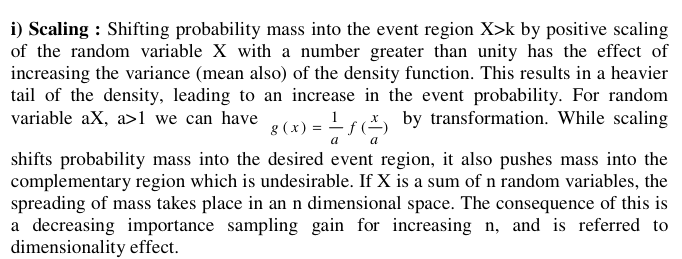

In [29]:
def scaled_prob(a, prob):
    return 1/a*prob

In [34]:
scaled_px = scaled_prob(0.8, probs)

In [39]:
weights = probs/scaled_px

In [40]:
weights.shape

(100, 24)

In [57]:
def peak_over_threshhold(alpha, values):
    return (values >= alpha) #sumamos en la dimensión de las muestras
    

In [65]:
def IS(probs, scale, alpha, samples):
    '''
    Realiza el Importance sampling.
    inputs:
    probs: probabilidades de cada muestra y cada instante de tiempo (100,24).
    scale: escala para la proposal distribution q(x), la que se utiliza en el importance sampling.
    alpha: cota que define un valor extremo.
    samples: Muestras (100,24).

    
    '''
    scaled_prob = 1/scale*probs # (100,24)
    weights = probs/scaled_prob # shape (100,24). Pesos para el importance sampling
    f = peak_over_threshhold(alpha, samples) #100,24

    return (f*weights).mean(axis=0) #devolvemos el promedio de las muestras.



In [71]:
def IMC(alpha, samples):
    f = peak_over_threshhold(alpha, samples)
    return f.mean(axis=0)

In [72]:
IMC(1, samples)

array([0.36, 0.38, 0.35, 0.4 , 0.54, 0.78, 0.99, 1.  , 1.  , 1.  , 0.99,
       0.98, 1.  , 1.  , 0.97, 0.88, 0.57, 0.26, 0.23, 0.37, 0.39, 0.43,
       0.35, 0.35])

In [70]:
IS(probs, 0.1, 1, samples)

array([0.03599999, 0.03799998, 0.03499999, 0.03999998, 0.05399997,
       0.07799995, 0.09900001, 0.10000002, 0.10000002, 0.10000002,
       0.09900001, 0.09800001, 0.10000002, 0.10000002, 0.09700001,
       0.08799997, 0.05699997, 0.026     , 0.023     , 0.03699999,
       0.03899999, 0.04299998, 0.03499999,        nan], dtype=float32)

# OLD

In [19]:
#trabajando con la primera serie

prediction_length = predictor.prediction_length
lead_time = predictor.lead_time
freq = predictor.freq

muestras = forecasts[0].samples
samples = muestras[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


In [20]:
muestras_mod = forecasts_mod[0].samples
samples_mod = muestras_mod[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


In [21]:
log_probs = forecasts[0].log_prob
log_probs_mod = forecasts_mod[0].log_prob

In [22]:
probs = np.exp(log_probs)
probs_mod = np.exp(log_probs_mod)

In [23]:
probs

array([[[1.42398250e+00, 5.58460772e-01, 6.96704835e-02, ...,
         9.87553224e-02, 6.06767684e-02, 2.88587958e-02],
        [1.99231148e+00, 1.37708560e-01, 6.71823844e-02, ...,
         7.81290978e-02, 7.44804367e-02, 1.25286609e-01],
        [2.06727600e+00, 5.30198328e-02, 4.11478095e-02, ...,
         3.91461104e-02, 6.42335564e-02, 1.17207840e-02],
        ...,
        [2.13406658e+00, 4.64058757e-01, 6.91721663e-02, ...,
         6.74902126e-02, 5.81004582e-02, 5.76549768e-02],
        [1.45814013e+00, 3.68610352e-01, 1.05186336e-01, ...,
         9.45977867e-02, 8.17396492e-02, 7.85255283e-02],
        [2.06440926e+00, 3.75792533e-01, 7.49553442e-02, ...,
         7.08741397e-02, 7.69270286e-02, 1.00964442e-01]],

       [[1.51930285e+00, 6.39698684e-01, 9.14997160e-02, ...,
         1.04071192e-01, 8.09311494e-02, 1.61463603e-01],
        [2.07262731e+00, 6.45267904e-01, 9.07340571e-02, ...,
         4.71388400e-02, 6.13759533e-02, 4.90417853e-02],
        [1.82693458e+00, 

In [24]:
probs_mod

array([[[6.66553557e-01, 1.74137801e-01, 1.10293128e-01, ...,
         9.71913263e-02, 7.58301020e-02, 1.48073360e-01],
        [6.90079629e-01, 1.91172466e-01, 6.40359372e-02, ...,
         3.90124545e-02, 2.93651484e-02, 1.14435256e-01],
        [6.27723217e-01, 1.40401319e-01, 5.87603450e-02, ...,
         4.36892845e-02, 9.33507904e-02, 6.49030320e-03],
        ...,
        [6.41693115e-01, 1.68921113e-01, 9.81189087e-02, ...,
         2.22635199e-03, 7.95036480e-02, 1.15178235e-01],
        [6.10983014e-01, 8.71239677e-02, 1.19913600e-01, ...,
         1.32435083e-01, 3.92831005e-02, 1.50037721e-01],
        [6.59303248e-01, 1.01261131e-01, 1.74993426e-01, ...,
         1.08338736e-01, 1.35923609e-01, 1.47481367e-01]],

       [[4.87900794e-01, 1.01698548e-01, 4.83534224e-02, ...,
         2.49449424e-02, 6.05296344e-02, 1.21256277e-01],
        [6.48628116e-01, 1.26420736e-01, 8.85545537e-02, ...,
         7.97063112e-02, 1.23269901e-01, 1.07083604e-01],
        [6.13514006e-01, 

In [25]:
probs[probs>1].shape

(131475,)

In [26]:
probs_mod[probs_mod>1].shape

(0,)

In [30]:
probs[probs>8].shape

(0,)

In [40]:
def rango_iqr(s, k, return_thresholds = False):
  # rango intercuantilico
  q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
  iqr = q75 - q25
  # Linea de corte.
  cut_off = iqr * k
  lower, upper = q25 - cut_off, q75 + cut_off
  print(f"Lower bound: {lower}\nUpper bound: {upper}")
  if return_thresholds:
      return lower, upper
  else: # identificar valores extremos
      return [True if x < lower or x > upper else False for x in s]
  
targets_df = pd.DataFrame()
targets_df["Target"] = target
targets_df.index = target_index

def graficar_extreme_values(k):

    targets_df["Extreme value"] = targets_df[["Target"]].apply(rango_iqr, k=k)
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

    col = np.where(targets_df['Extreme value'] == True, 'blue', 'silver')
    ax.scatter(targets_df.index, targets_df['Target'], c=col)
    ax.set_title('Extreme values para todos los años', size=18)
    ax.set_ylabel("Generacion [MW]")
    ax.set_xlabel('Fecha')

    plt.tight_layout()
    plt.show()

Lower bound: -118.72500228881836
Upper bound: 158.3000030517578


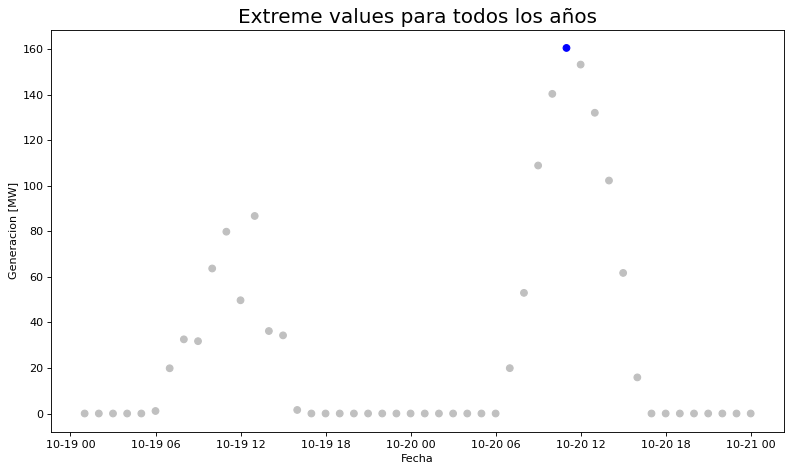

In [43]:
graficar_extreme_values(3)

In [44]:
def indicatriz(arr, alpha):
    if np.any(arr > alpha):
        return 1
    else:
        return 0
    
def MC(f, samples, alpha):
    sum = 0
    for i in range(samples.shape[0]):
        function_value = f(samples[i,:], alpha)
        sum+=function_value
    
    return (sum/samples.shape[0])


In [45]:
MC(indicatriz, samples, alpha = 158.3000030517578)

0.0

# Pruebas distribución


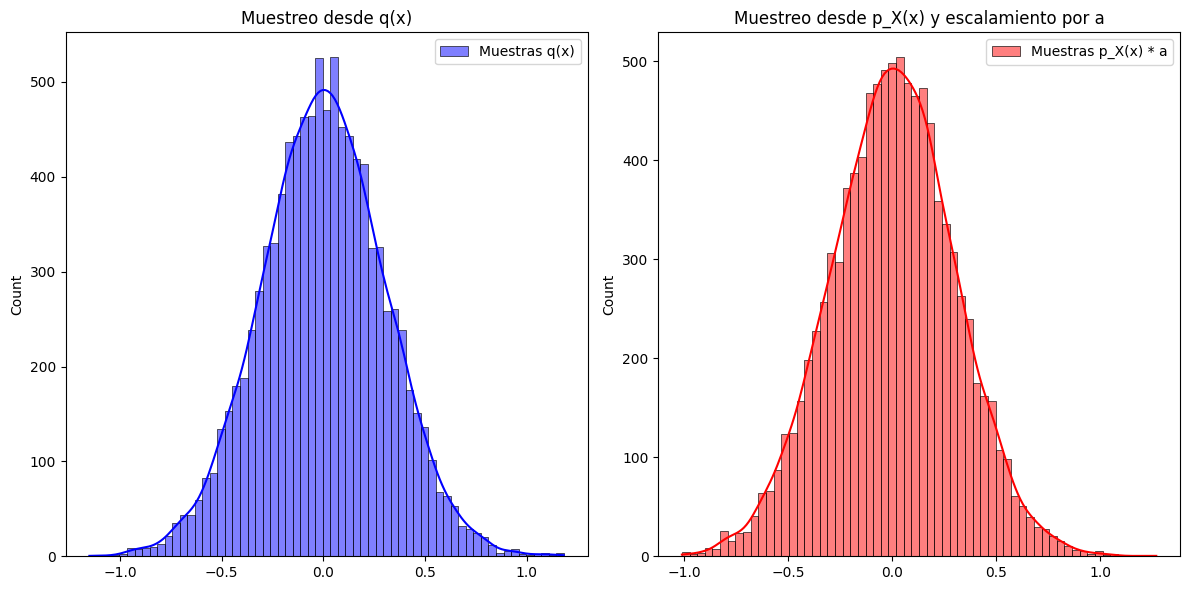

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Parámetros
mu_X = 0
sigma_X = 1
a = 0.3

# Distribución objetivo p_X(x)
p_X = stats.norm(mu_X, sigma_X)

# Distribución de propuesta q(x)
mu_q = mu_X * a
sigma_q = sigma_X * a
q = stats.norm(mu_q, sigma_q)

# Número de muestras
N = 10000

# Muestreo directo desde q(x)
samples_q = q.rvs(N)

# Muestreo desde p_X(x) y escalamiento por a
samples_p_scaled = p_X.rvs(N) * a

# Histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Muestreo desde q(x)')
sns.histplot(samples_q, kde=True, color='blue', label='Muestras q(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Muestreo desde p_X(x) y escalamiento por a')
sns.histplot(samples_p_scaled, kde=True, color='red', label='Muestras p_X(x) * a')
plt.legend()

plt.tight_layout()
plt.show()


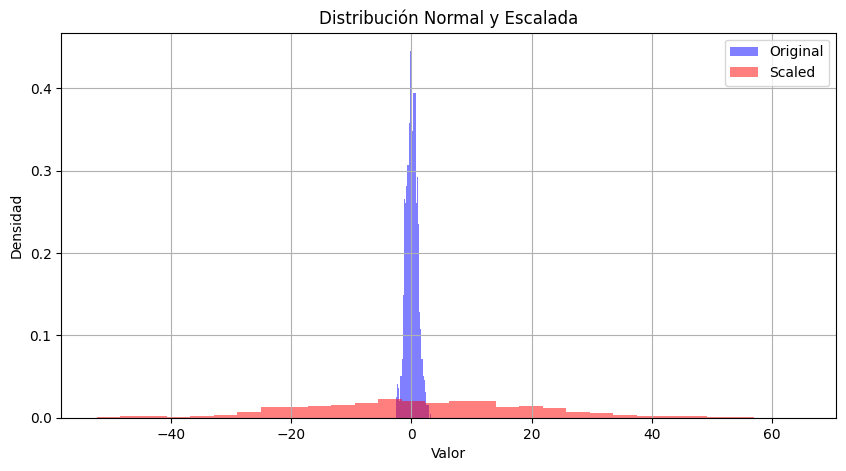

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar muestras de una distribución normal con media 0 y desviación estándar 1
mu = 0
sigma = 1
sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

# Graficar el histograma de las muestras originales
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=30, density=True, alpha=0.5, color='b', label='Original')

# Escalar las muestras
scaled_samples = samples * 20  # Escalar por un factor de 2

# Graficar el histograma de las muestras escaladas
plt.hist(scaled_samples, bins=30, density=True, alpha=0.5, color='r', label='Scaled')

plt.title('Distribución Normal y Escalada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()